# Exploració de dades — TCGA-COAD CMS

Anàlisi exploratòria del conjunt de dades d'expressió gènica del projecte TCGA-COAD (*The Cancer Genome Atlas — Colon Adenocarcinoma*) preprocessat per a la classificació supervisada de subtipus moleculars CMS.

## Fitxa tècnica

| Paràmetre | Valor |
|-----------|-------|
| Conjunt de dades | TCGA-COAD |
| Plataforma | RNA-seq (Illumina HiSeq) |
| Unitat original | FPKM (*Fragments Per Kilobase Million*) |
| Transformació aplicada | log₂(FPKM + 1) |
| Sistema de classificació | CMS (*Consensus Molecular Subtypes*) |
| Subtipus objectiu | CMS1, CMS2, CMS3, CMS4 |
| Partició | 80% entrenament / 20% test |
| Fitxers d'entrada | `data/processed/X_train.csv`, `data/processed/X_test.csv`, `data/processed/y_train.csv`, `data/processed/y_test.csv` |

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore", message="IProgress not found", category=UserWarning)
import umap
from sklearn.decomposition import PCA

import sys
sys.path.insert(0, str(Path(".").resolve().parent))
from src.gdc_utils import repo_root

ROOT = repo_root()
PROCESSED_DIR = ROOT / "data" / "processed"
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

/home/mrivero/miniforge3/envs/tcga-coad-cms-ml-pipeline/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Introducció al conjunt de dades

Les dades d'entrada provenen de mostres de càncer colorectal del projecte TCGA-COAD, mesurades amb tecnologia RNA-seq (Illumina HiSeq). Cada mostra es representa com un vector d'expressió gènica d'alta dimensió, on cada component correspon a un gen i el valor reflecteix el nivell d'expressió mesurat en FPKM.

Les dades de RNA-seq presenten una alta dimensionalitat intrínseca: el nombre de variables (gens) supera àmpliament el nombre de mostres disponibles, fenomen conegut com *p ≫ n*. Alharbi i Vakanski (2022) identifiquen aquest desequilibri com una de les principals dificultats dels models supervisats en dades biomèdiques, i recomanen aplicar transformació logarítmica i filtratge de gens de baixa expressió com a passos de preprocessament estàndard.

**Referència:** Alharbi, F., & Vakanski, A. (2022). Machine learning methods for cancer classification using gene expression data: A review. *Bioengineering*, 9(5), 220.

## 2. Variable objectiu: subtipus CMS

La variable objectiu és el subtipus molecular consensuat (CMS), definit per Guinney et al. (2015) a partir de sis algorismes de classificació independents aplicats a dades d'expressió gènica de càncer colorectal. Cada subtipus presenta un perfil biològic i un pronòstic clínic diferenciat:

| Subtipus | Característiques principals | Freqüència aproximada |
|----------|----------------------------|-----------------------|
| CMS1 | Hipermutació, activació immune | ~14% |
| CMS2 | Activació de WNT i MYC, perfil epitelial | ~37% |
| CMS3 | Desregulació metabòlica, mutació KRAS | ~13% |
| CMS4 | Activació de TGF-β, perfil mesenquimal | ~23% |

Les mostres sense assignació CMS unívoca s'exclouen del pipeline durant l'etapa de preprocessament.

**Referència:** Guinney, J., et al. (2015). The consensus molecular subtypes of colorectal cancer. *Nature Medicine*, 21(11), 1350–1356.

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train.csv", index_col=0)
X_test = pd.read_csv(PROCESSED_DIR / "X_test.csv", index_col=0)
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv", index_col=0).squeeze("columns")
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv", index_col=0).squeeze("columns")

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}")

X_train: (296, 15625)  |  X_test: (74, 15625)
y_train: (296,)  |  y_test: (74,)


## 3. Traçabilitat del pipeline de preprocessament

L'etapa de preprocessament genera un registre JSON (`data/processed/preprocessing_log.json`) amb els paràmetres i comptadors de cada pas. La consulta d'aquest registre permet verificar la reproducibilitat del pipeline sense necessitat de reexecutar-lo.

In [3]:
log_path = ROOT / "data" / "processed" / "preprocessing_log.json"
with open(log_path) as f:
    prep_log = json.load(f)

rows = [(k, v) for k, v in prep_log.items() if not isinstance(v, dict)]
pd.DataFrame(rows, columns=["Paràmetre", "Valor"]).set_index("Paràmetre")

,Valor
Paràmetre,
timestamp,2026-05-19T19:33:45.336278+00:00
random_seed,42
test_size,0.2
min_count_threshold,10
min_sample_fraction,0.2
raw_files_found,483
samples_after_dedup,370
samples_with_cms_labels,370
train_samples,296


El registre confirma la correspondència entre el nombre de mostres i gens en cada etapa. El nombre total de mostres és consistent amb la partició 80/20 reportada a la fitxa tècnica, i el nombre de gens reflecteix el resultat del filtratge descrit a la secció 4.

## 4. Preprocessament aplicat

### 4.1 Justificació de les transformacions

Les dades RNA-seq crues presenten una distribució fortament asimètrica: la majoria de gens mostren valors baixos o nuls, mentre que un conjunt reduït de gens altament expressats acumula la major part de la variança total. Dues transformacions s'apliquen de manera conjunta per reduir aquest efecte:

1. **Filtratge de gens de baixa expressió**: elimina gens no expressats o gairebé no expressats en la majoria de mostres, reduint la dimensionalitat i el soroll sense perdre informació biològicament rellevant.
2. **Transformació logarítmica log₂(x + 1)**: comprimeix la distribució asimètrica, redueix la influència dels valors extrems i millora l'escala dels valors per als classificadors de l'etapa de modelatge.

### 4.2 Criteri de filtratge

El filtratge s'aplica exclusivament sobre el conjunt d'entrenament. Això evita la fuga d'informació (*data leakage*): si el criteri de selecció de gens incorporés informació del conjunt de test, les mètriques d'avaluació no serien una estimació honesta del rendiment en dades noves. El llindar d'expressió mínim es registra al `preprocessing_log.json`.

In [4]:
filter_rate = prep_log.get("filter_min_expression_rate", "N/A")
genes_before = prep_log.get("genes_before_filter", "N/A")
genes_after = prep_log.get("genes_after_filter", "N/A")

decisions = pd.DataFrame({
    "Transformació": ["Filtratge de gens", "Transformació log₂(x+1)"],
    "Criteri": [
        f"Taxa d'expressió > {filter_rate}",
        "Aplicada a tots els valors (FPKM)"
    ],
    "Aplicada sobre": ["Conjunt d'entrenament", "Tots els conjunts"],
    "Gens (abans → després)": [
        f"{genes_before} → {genes_after}",
        f"{genes_after} → {genes_after}"
    ]
})
decisions

,Transformació,Criteri,Aplicada sobre,Gens (abans → després)
0,Filtratge de gens,Taxa d'expressió > N/A,Conjunt d'entrenament,N/A → N/A
1,Transformació log₂(x+1),Aplicada a tots els valors (FPKM),Tots els conjunts,N/A → N/A


### 4.3 Efecte del filtratge sobre la distribució de gens

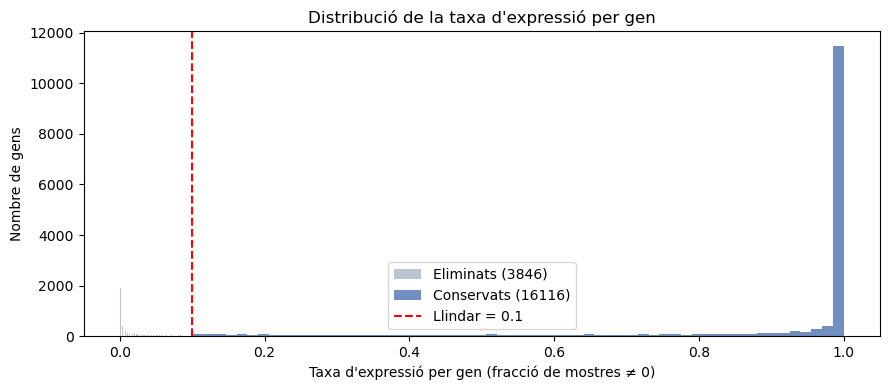

In [5]:
filter_stats_path = ROOT / "data" / "processed" / "gene_filter_stats.csv"
if filter_stats_path.exists():
    filter_stats = pd.read_csv(filter_stats_path)
    threshold = prep_log.get("filter_min_expression_rate", 0.1)

    fig, ax = plt.subplots(figsize=(9, 4))
    kept = filter_stats["expression_rate"] > threshold
    ax.hist(filter_stats.loc[~kept, "expression_rate"], bins=60,
            color="#aab7c4", alpha=0.8, label=f"Eliminats ({(~kept).sum()})")
    ax.hist(filter_stats.loc[kept, "expression_rate"], bins=60,
            color="#4C72B0", alpha=0.8, label=f"Conservats ({kept.sum()})")
    ax.axvline(threshold, color="red", linestyle="--", linewidth=1.5,
               label=f"Llindar = {threshold}")
    ax.set_xlabel("Taxa d'expressió per gen (fracció de mostres ≠ 0)")
    ax.set_ylabel("Nombre de gens")
    ax.set_title("Distribució de la taxa d'expressió per gen")
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "gene_expression_rate.png", dpi=150)
    plt.show()
else:
    print("gene_filter_stats.csv no disponible. Executeu scripts/preprocess.py primer.")

La distribució de taxes d'expressió mostra que una proporció significativa de gens presenten expressió nul·la o molt baixa en la majoria de mostres. El filtratge elimina aquests gens no informatius i redueix la dimensionalitat del conjunt sense perdre gens biològicament rellevants per a la classificació CMS.

### 4.4 Efecte de la transformació logarítmica

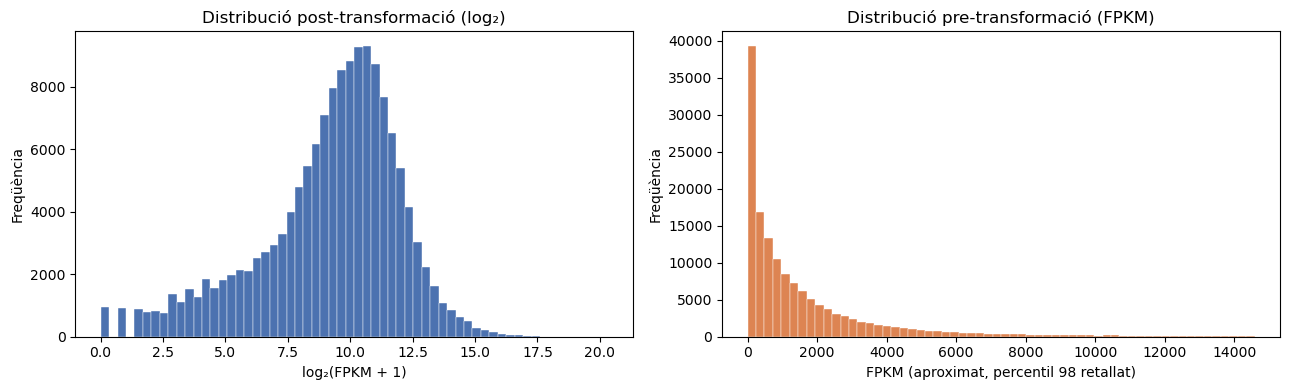

In [6]:
sample_vals = X_train.values[:, :500].flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sample_vals, bins=60, color="#4C72B0", edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("log₂(FPKM + 1)")
axes[0].set_ylabel("Freqüència")
axes[0].set_title("Distribució post-transformació (log₂)")

raw_approx = 2**sample_vals - 1
raw_clipped = raw_approx[raw_approx < np.percentile(raw_approx, 98)]
axes[1].hist(raw_clipped, bins=60, color="#DD8452", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("FPKM (aproximat, percentil 98 retallat)")
axes[1].set_ylabel("Freqüència")
axes[1].set_title("Distribució pre-transformació (FPKM)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "log_transformation_effect.png", dpi=150)
plt.show()

La transformació log₂(x + 1) redueix substancialment l'asimetria de la distribució original. Els valors transformats es distribueixen de manera més simètrica i en una escala adequada per als classificadors de l'etapa de modelatge. El sumand +1 evita logaritmes de zero per a gens no expressats.

## 5. Distribució de la variable objectiu

La distribució de subtipus CMS al conjunt d'entrenament i al conjunt de test determina el grau de desbalanceig de classes. Un desbalanceig marcat afecta la funció de pèrdua dels classificadors i pot biaixar les prediccions cap a les classes majoritàries.

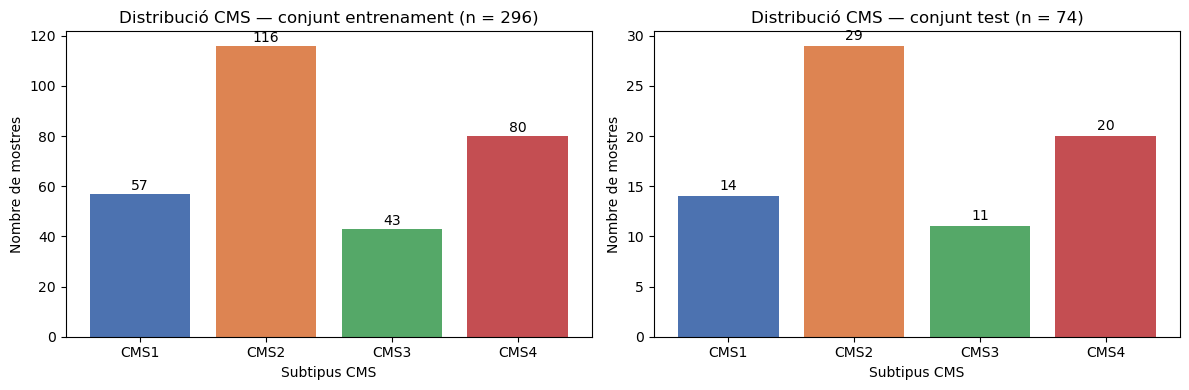

Distribució train (n, %):
             n   pct
cms_label           
CMS1        57  19.3
CMS2       116  39.2
CMS3        43  14.5
CMS4        80  27.0

Distribució test (n, %):
            n   pct
cms_label          
CMS1       14  18.9
CMS2       29  39.2
CMS3       11  14.9
CMS4       20  27.0


In [7]:
cms_colors = {"CMS1": "#4C72B0", "CMS2": "#DD8452", "CMS3": "#55A868", "CMS4": "#C44E52"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (y, split) in zip(axes, [(y_train, "entrenament"), (y_test, "test")]):
    counts = y.value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values,
                  color=[cms_colors[c] for c in counts.index])
    ax.set_xlabel("Subtipus CMS")
    ax.set_ylabel("Nombre de mostres")
    ax.set_title(f"Distribució CMS — conjunt {split} (n = {len(y)})")
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3, str(count),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "cms_distribution.png", dpi=150)
plt.show()

print("Distribució train (n, %):")
print(y_train.value_counts().sort_index().to_frame("n")
      .assign(pct=lambda df: (df.n / df.n.sum() * 100).round(1)))
print("\nDistribució test (n, %):")
print(y_test.value_counts().sort_index().to_frame("n")
      .assign(pct=lambda df: (df.n / df.n.sum() * 100).round(1)))

CMS2 és el subtipus majoritari tant al conjunt d'entrenament com al de test. CMS3 és la classe minoritària, amb una representació inferior al 15% del total de mostres en ambdós conjunts. Aquest desbalanceig justifica l'ús del paràmetre `class_weight='balanced'` durant l'entrenament, de manera que cada classe contribueixi equitativament a la funció de pèrdua independentment de la seva freqüència absoluta.

## 6. Anàlisi de components principals (PCA)

L'Anàlisi de Components Principals projecta les dades en un subespai de menor dimensió maximitzant la variança retinguda. El PCA es calcula sobre les dades d'entrenament i s'aplica la mateixa transformació al conjunt de test. S'utilitza exclusivament amb finalitat exploratòria: el PCA **no s'utilitza com a entrada dels classificadors**.

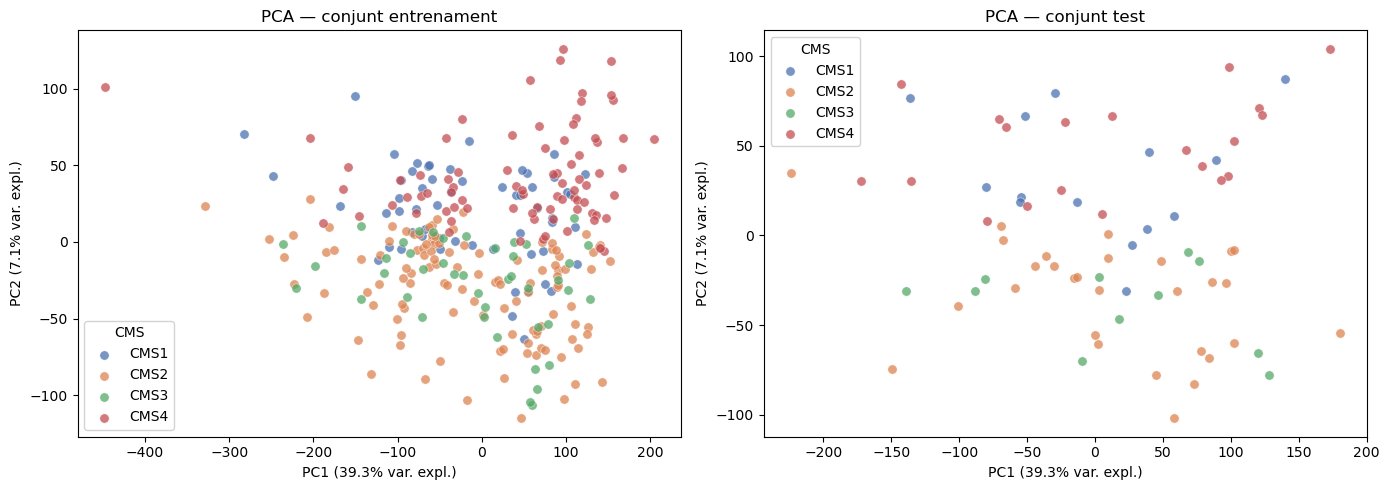

Variança explicada — PC1: 39.31%, PC2: 7.11%, Total: 46.42%


In [8]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (X_pca, y, split) in zip(axes, [
    (X_train_pca, y_train, "entrenament"),
    (X_test_pca, y_test, "test"),
]):
    for cms in sorted(y.unique()):
        mask = y == cms
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=cms, color=cms_colors[cms],
                   alpha=0.75, s=45, edgecolors="white", linewidths=0.4)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var. expl.)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var. expl.)")
    ax.set_title(f"PCA — conjunt {split}")
    ax.legend(title="CMS", framealpha=0.85)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "pca_cms.png", dpi=150)
plt.show()

print(f"Variança explicada — PC1: {pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2: {pca.explained_variance_ratio_[1]:.2%}, "
      f"Total: {pca.explained_variance_ratio_[:2].sum():.2%}")

La projecció PCA revela una separació parcial entre subtipus CMS en les dues primeres components principals. CMS2 i CMS4 tendeixen a ocupar regions diferenciades de l'espai de projecció, mentre que CMS1 i CMS3 mostren una major superposició. La variança acumulada explicada per PC1 i PC2 és moderada, resultat esperat donat l'elevat nombre de dimensions del conjunt original (*p ≫ n*).

### 6.1 Gens amb major contribució a PC1 i PC2

Els *loadings* del PCA indiquen quins gens contribueixen més a la variança de cada component principal. Els gens amb valors absoluts de *loading* més elevats representen els principals factors d'expressió que diferencien les mostres.

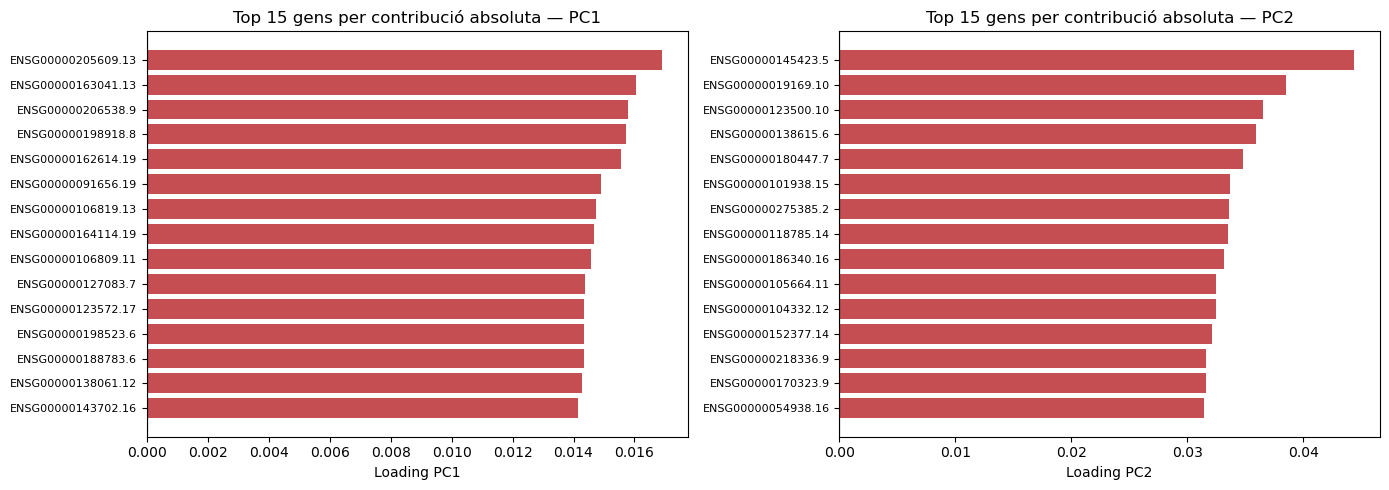

In [9]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_train.columns,
    columns=["PC1", "PC2"],
)

top_n = 15
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, pc in zip(axes, ["PC1", "PC2"]):
    top_genes = loadings[pc].abs().nlargest(top_n).index
    top_vals = loadings.loc[top_genes, pc].sort_values()
    colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top_vals]
    ax.barh(range(top_n), top_vals.values, color=colors)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_vals.index, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"Loading {pc}")
    ax.set_title(f"Top {top_n} gens per contribució absoluta — {pc}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "gene_loadings_pca.png", dpi=150)
plt.show()

## 7. Reducció no lineal: UMAP

UMAP (*Uniform Manifold Approximation and Projection*) és un algorisme de reducció de dimensionalitat no lineal que preserva l'estructura local i global del conjunt de dades millor que el PCA en presència de relacions no lineals. S'aplica exclusivament amb finalitat exploratòria sobre el conjunt d'entrenament.

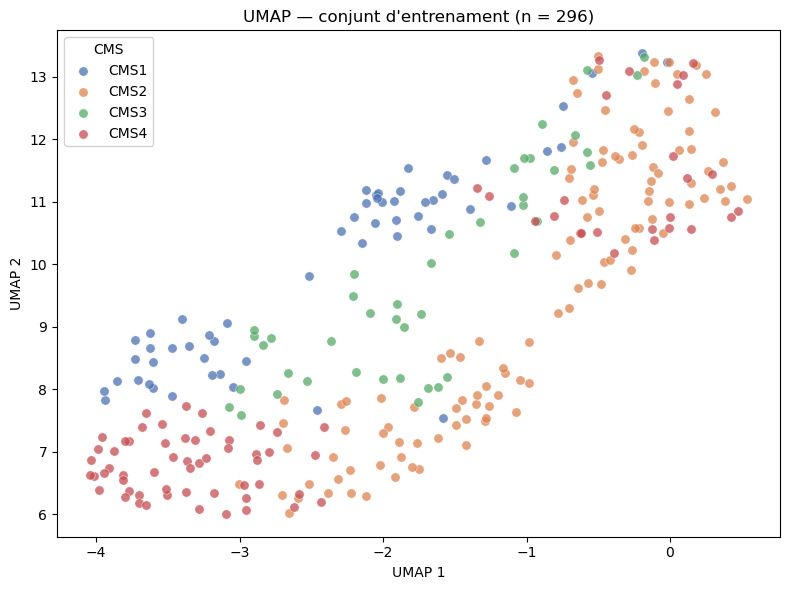

In [10]:
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
X_train_umap = reducer.fit_transform(X_train)

fig, ax = plt.subplots(figsize=(8, 6))
for cms in sorted(y_train.unique()):
    mask = y_train == cms
    ax.scatter(X_train_umap[mask, 0], X_train_umap[mask, 1],
               label=cms, color=cms_colors[cms],
               alpha=0.75, s=45, edgecolors="white", linewidths=0.4)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP — conjunt d'entrenament (n = {})".format(len(y_train)))
ax.legend(title="CMS", framealpha=0.85)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "umap_cms.png", dpi=150)
plt.show()

La projecció UMAP sobre el conjunt d'entrenament mostra una separació parcial de les mostres per subtipus CMS. CMS2 i CMS4 tendeixen a formar agrupaments més compactes, mentre que CMS3 presenta una distribució més dispersa, consistent amb el seu perfil biològic menys diferenciat. Aquestes observacions corroboren que existeix estructura de separació en les dades i justifiquen l'ús de classificadors supervisats en l'etapa de modelatge.

## 10. Conclusions de l'exploració de dades

L'exploració realitzada permet concloure que les dades preprocessades presenten una estructura coherent i són aptes per a l'etapa posterior de modelatge. La traçabilitat del pipeline mostra una reducció controlada del nombre de variables, i les comprovacions finals confirmen la correspondència entre mostres, etiquetes i gens.

El filtratge de baixa expressió i la transformació logarítmica redueixen soroll i milloren l'escala dels valors d'expressió. Les visualitzacions PCA i UMAP indiquen una separació parcial de les mostres segons les etiquetes CMS, fet que justifica continuar amb l'entrenament de classificadors supervisats.

Les limitacions principals del conjunt són l'alta dimensionalitat, el nombre moderat de mostres i el desbalanceig entre classes. Aquestes característiques es tenen en compte en el notebook dedicat als models.